# Model Evaluation for Classification
* Learning curve
* Validation curve

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(
    StandardScaler(), LogisticRegression(solver="liblinear", random_state=1)
)

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print("Score: %.3f" % pipe_lr.score(X_test, y_test))

Score: 0.965


## Evaluating Models Using a Learning Curve

* Use the `learning_curve` function.
* We aim to assess how the number of training samples affects model performance.


In [5]:
from sklearn.model_selection import learning_curve


pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="liblinear", penalty="l2", random_state=1),
)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe_lr,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=10,
    n_jobs=1,
)

In [6]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

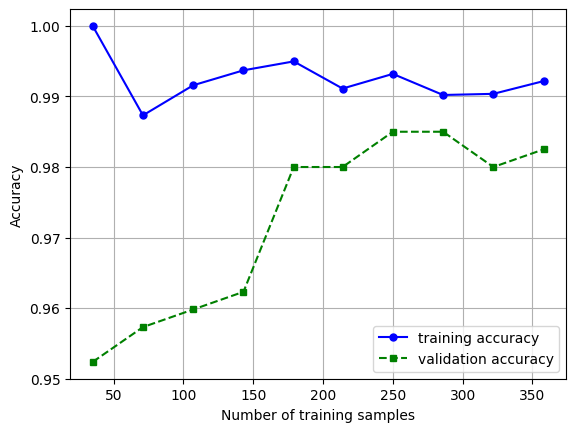

In [ ]:
plt.plot(
    train_sizes,
    train_mean,
    color="blue",
    marker="o",
    markersize=5,
    label="training accuracy",
)

plt.plot(
    train_sizes,
    test_mean,
    color="green",
    linestyle="--",
    marker="s",
    markersize=5,
    label="validation accuracy",
)
plt.grid()
plt.xlabel("Number of training samples")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")

* The `train_sizes` parameter is used to generate 10 different proportions of the training set, ranging from 0.1 to 1.0.
* Use the `cv` parameter to apply 10-fold cross-validation.
* Visualize both training accuracy and validation accuracy.
* The model performs well when the training data ratio is above 0.7 (approximately 250 samples).



## Evaluating Models Using a Validation Curve

* We evaluate how changes in certain hyperparameters affect model performance.
* Use the `validation_curve` function:
    * `param_name`: The name of the hyperparameter to be changed.
    * `param_range`: The range of values to use for the hyperparameter.


In [8]:
from sklearn.model_selection import validation_curve


param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
    estimator=pipe_lr,
    X=X_train,
    y=y_train,
    param_name="logisticregression__C",  # 로지스틱 회귀에서 규제
    param_range=param_range,
    cv=10,
)

In [9]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

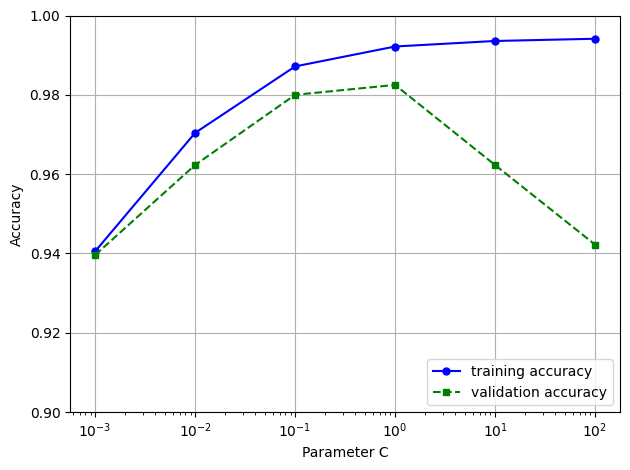

In [10]:
plt.plot(
    param_range,
    train_mean,
    color="blue",
    marker="o",
    markersize=5,
    label="training accuracy",
)
plt.plot(
    param_range,
    test_mean,
    color="green",
    linestyle="--",
    marker="s",
    markersize=5,
    label="validation accuracy",
)
plt.grid()
plt.xscale("log")
plt.legend(loc="lower right")
plt.xlabel("Parameter C")
plt.ylabel("Accuracy")
plt.ylim([0.9, 1.00])
plt.tight_layout()
plt.show()

* The `validation_curve` function estimates model performance using cross-validation by default.
* You specify the hyperparameter to evaluate within the function.
* Example: `param_name='logisticregression__C'` — this refers to the `C` parameter of the Logistic Regression model.
* Increasing the value of `C` reduces regularization, which may lead to slight overfitting.
* In this case, the optimal values appear to be `0.01` or `0.1`.